In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
os.chdir('/content/drive/MyDrive/BUDT757/BUDT757 Group 3 Project/')
#

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('Data/enron_spam_data.csv')

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Message ID  33716 non-null  int64 
 1   Subject     33427 non-null  object
 2   Message     33345 non-null  object
 3   Spam/Ham    33716 non-null  object
 4   Date        33716 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.3+ MB
None


In [12]:
print(df['Spam/Ham'].value_counts())
print(f"Ratio of Spam: ", df['Spam/Ham'].value_counts().iloc[0]  / len(df['Spam/Ham']))

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64
Ratio of Spam:  0.5092834262664611


In [13]:
print(df.isna().sum())

Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64


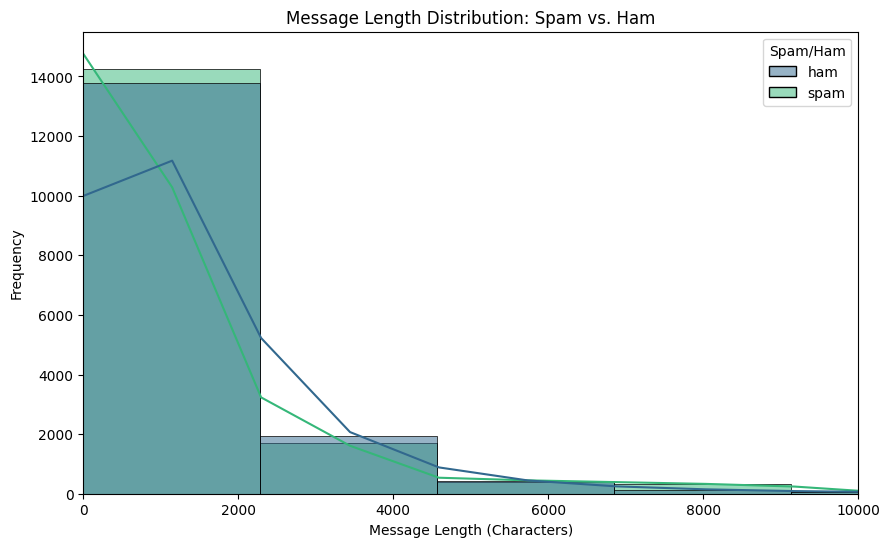

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate message lengths (excluding nulls)
df['msg_length'] = df['Message'].dropna().str.len()

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='msg_length', hue='Spam/Ham', bins=100, kde=True, palette='viridis')
plt.title('Message Length Distribution: Spam vs. Ham')
plt.xlabel('Message Length (Characters)')
plt.ylabel('Frequency')
plt.xlim(0, 10000) # Capped at 10k to see the bulk of the distribution
plt.show()

In [15]:
import re

# Drop nulls and extract all words
all_text = " ".join(df['Message'].dropna().astype(str).str.lower())
# Tokenize using regex (words only)
tokens = re.findall(r'\b\w+\b', all_text)
vocab_size = len(set(tokens))

print(f"Total Number of Tokens: {len(tokens)}")
print(f"Unique Vocabulary Size: {vocab_size}")

Total Number of Tokens: 8001115
Unique Vocabulary Size: 155266


Feature distributions of interest

/tmp/ipython-input-1040374403.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='cap_ratio', hue='Spam/Ham', fill=True, ax=axes[1])


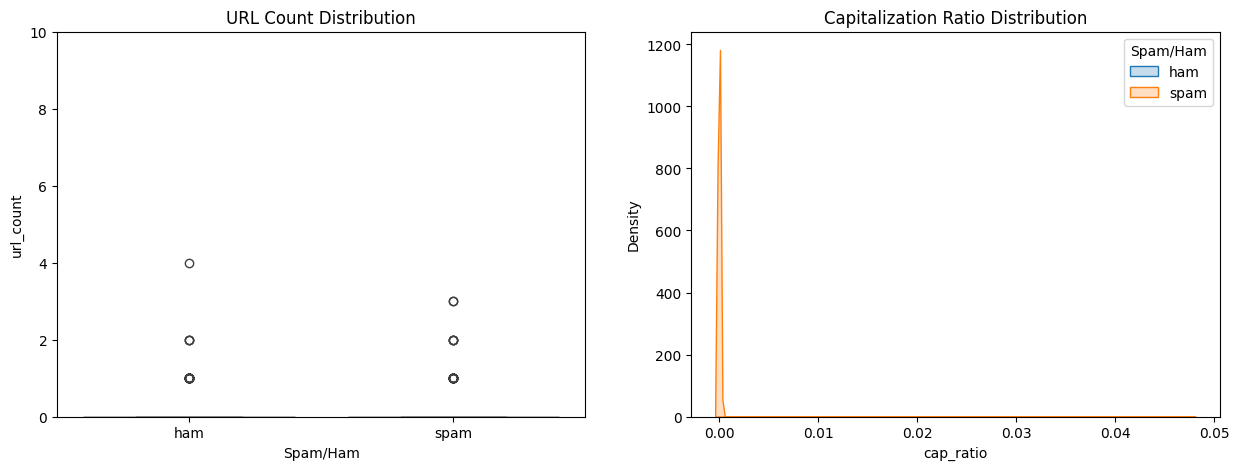

In [17]:
# Heavy punction / Agression
# import pnkt.punctuation
df['excl_count'] = df['Message'].dropna().apply(lambda x: x.count('!'))

def capitalization_ratio(text):
  text = str(text)
  uppers = [letter for letter in text if letter.isupper()]
  return len(uppers) / len(text) if len(text) > 0 else 0

df['cap_ratio'] = df['Message'].dropna().apply(capitalization_ratio)

#Count of Urls
df['url_count'] = df['Message'].dropna().apply(lambda x: len(re.findall(r'http[s]', str(x))))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='Spam/Ham', y='url_count', data=df, ax=axes[0])
axes[0].set_title('URL Count Distribution')
axes[0].set_ylim(0, 10) # Zoom in to see the bulk

sns.kdeplot(data=df, x='cap_ratio', hue='Spam/Ham', fill=True, ax=axes[1])
axes[1].set_title('Capitalization Ratio Distribution')

plt.show()